# Preprocessing v2.0 — Semua Skenario (A-Manual, A-Gabungan, B-Gabungan)

## Desain Splitting
| Skenario | Train | Test | Sumber Test |
|---|---|---|---|
| A-Manual | 80% manual | 20% manual (~3.194) | Manual murni |
| A-Gabungan | 80% gabungan | 20% gabungan (~11.839) | Gabungan 20% |
| B-Gabungan | 80% gabungan | **3.194 dari gabungan** | Sample gabungan |

## Eksperimen (9 total)
```
LR      : A-Manual, A-Gabungan, B-Gabungan
XGB NoTune: A-Manual, A-Gabungan, B-Gabungan
XGB Tuned : A-Manual (~22 mnt), A-Gabungan (~90 mnt), B-Gabungan (~90 mnt)
```

## Alur Notebook
```
Cell 1  → Setup & konfigurasi
Cell 2  → Splitting (3 skenario)
Cell 3  → Fungsi TF-IDF Bigram + Evaluasi
Cell 4  → LR (A-Manual, A-Gabungan, B-Gabungan)
Cell 5  → XGB NoTune (A-Manual, A-Gabungan, B-Gabungan)
Cell 6a → XGB Tuned A-Manual (~22 menit)
Cell 6b → XGB Tuned A-Gabungan (~90 menit)
Cell 6c → XGB Tuned B-Gabungan (~90 menit)
Cell 7  → Perbandingan lengkap v1.0 vs v2.0
```


> **Update:** Bagian *Cell 2b* ditambahkan untuk melakukan splitting pada data hasil *preprocessing* IndoBERT (`data_preprocessed_indobert_3.0.csv`), mengikuti skenario dan metodologi yang sama persis dengan Cell 2 (A-Manual, A-Gabungan, B-Gabungan).

## Cell 1 — Setup & Konfigurasi

In [1]:
import pandas as pd
import numpy as np
import os, pickle, time, warnings
warnings.filterwarnings('ignore')

import xgboost as xgb
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, classification_report
)

# ── PATH ─────────────────────────────────────────────────────────────────────
BASE_DIR   = r'C:\Users\Lenovo\Downloads\skrips_code\xgboost_indobert_method'
PREP_DIR   = os.path.join(BASE_DIR, 'data/processed')
SPLIT_DIR  = os.path.join(BASE_DIR, 'data/splits/splits_v3')
MODEL_DIR  = os.path.join(BASE_DIR, 'models')
RESULT_DIR = os.path.join(BASE_DIR, 'results')
for d in [SPLIT_DIR, MODEL_DIR, RESULT_DIR]:
    os.makedirs(d, exist_ok=True)

SEED        = 42
LABEL_MAP   = {'keluhan': 0, 'saran': 1, 'pujian': 2}
CLASS_NAMES = ['keluhan', 'saran', 'pujian']

# k_best optimal (dari grid search k sebelumnya)
K_MANUAL   = 2000
K_GABUNGAN = 15000

# ── Hasil v1.0 untuk perbandingan ─────────────────────────────────────────────
HASIL_V1 = {
    # LR
    'LR-A-Manual'         : {'acc':79.13,'f1':0.7582,'f1_k':0.8499,'f1_s':0.5893,'f1_p':0.8355},
    'LR-A-Gabungan'       : {'acc':81.20,'f1':0.7675,'f1_k':0.8684,'f1_s':0.5941,'f1_p':0.8401},
    'LR-B-Gabungan'       : {'acc':80.96,'f1':0.7677,'f1_k':0.8677,'f1_s':0.5998,'f1_p':0.8354},
    # XGB NoTune
    'XGB-NoTune-A-Manual'   : {'acc':77.86,'f1':0.7473,'f1_k':0.8416,'f1_s':0.5727,'f1_p':0.8275},
    'XGB-NoTune-A-Gabungan' : {'acc':78.80,'f1':0.7458,'f1_k':0.8521,'f1_s':0.5510,'f1_p':0.8344},
    'XGB-NoTune-B-Gabungan' : {'acc':78.29,'f1':0.7417,'f1_k':0.8489,'f1_s':0.5474,'f1_p':0.8290},
    # XGB Tuned
    'XGB-Tuned-A-Manual'    : {'acc':79.49,'f1':0.7574,'f1_k':0.8541,'f1_s':0.5880,'f1_p':0.8301},
    'XGB-Tuned-A-Gabungan'  : {'acc':82.27,'f1':0.7750,'f1_k':0.8793,'f1_s':0.5923,'f1_p':0.8532},
    'XGB-Tuned-B-Gabungan'  : {'acc':81.73,'f1':0.7685,'f1_k':0.8774,'f1_s':0.5837,'f1_p':0.8444},
}

# Cek file preprocessed
path_full = os.path.join(PREP_DIR, 'data_preprocessed_v2.csv')
if os.path.exists(path_full):
    _df = pd.read_csv(path_full)
    print(f'✅ data_preprocessed_v2.csv: {len(_df):,} baris')
    del _df
else:
    print('❌ File tidak ditemukan! Jalankan notebook preprocessing_v2_final dulu.')
print('\n✅ Setup selesai!')

✅ data_preprocessed_v2.csv: 59,864 baris

✅ Setup selesai!


## Cell 2 — Splitting (3 Skenario)

```
A-Manual   : 80% manual train  | 20% manual test (~3.194)
A-Gabungan : 80% gab train     | 20% gab test  (~11.839)
B-Gabungan : 80% gab train     | 3.194 baris dari gabungan sebagai test
```


In [2]:
# Load data preprocessed v2.0
print('Loading data_preprocessed_v2.csv...')
df = pd.read_csv(os.path.join(PREP_DIR, 'data_preprocessed_v2.csv'))
df['label_enc'] = df['label_pks'].map(LABEL_MAP)
print(f'Total: {len(df):,} baris')

# Pisah manual vs otomatis
df_manual = df[df['confidence'] == 1.0].copy().reset_index(drop=True)
df_auto   = df[df['confidence'] <  1.0].copy().reset_index(drop=True)
df_gab    = df.copy().reset_index(drop=True)

print(f'  Manual (conf=1.0)   : {len(df_manual):,}')
print(f'  Otomatis (conf<1.0) : {len(df_auto):,}')
print(f'  Gabungan (total)    : {len(df_gab):,}')

# ── A-Manual: 80:20 dari data manual ─────────────────────────────────────────
man_train, man_test = train_test_split(
    df_manual, test_size=0.2, random_state=SEED,
    stratify=df_manual['label_enc']
)

# ── A-Gabungan: 80:20 dari data GABUNGAN ──────────────────────────────────────
agab_train, agab_test = train_test_split(
    df_gab, test_size=0.2, random_state=SEED,
    stratify=df_gab['label_enc']
)

# ── B-Gabungan: train=80% gabungan | test=3.194 dari GABUNGAN ────────────────
# test_size = jumlah baris yang sama dengan man_test (bukan manual murni)
bgab_train, bgab_test = train_test_split(
    df_gab,
    test_size=len(man_test),   # ← 3.194 baris dari gabungan
    random_state=SEED,
    stratify=df_gab['label_enc']
)

# ── Ringkasan ────────────────────────────────────────────────────────────────
print(f'\n{"="*65}')
print(f'{"Skenario":15s} {"N Train":>10s} {"N Test":>10s} {"Sumber Test"}')
print(f'{"─"*65}')
print(f'{"A-Manual":15s} {len(man_train):>10,} {len(man_test):>10,}  20% manual murni')
print(f'{"A-Gabungan":15s} {len(agab_train):>10,} {len(agab_test):>10,}  20% gabungan')
print(f'{"B-Gabungan":15s} {len(bgab_train):>10,} {len(bgab_test):>10,}  {len(man_test)} baris dari gabungan')
print(f'{"="*65}')

# Validasi B-Gabungan
n_man_in_b = (bgab_test['confidence'] == 1.0).sum()
n_aut_in_b = (bgab_test['confidence'] <  1.0).sum()
print(f'\nKomposisi test B-Gabungan ({len(bgab_test):,} baris):')
print(f'  Manual (conf=1.0)   : {n_man_in_b:,} ({n_man_in_b/len(bgab_test)*100:.1f}%)')
print(f'  Otomatis (conf<1.0) : {n_aut_in_b:,}  ({n_aut_in_b/len(bgab_test)*100:.1f}%)')
print(f'\nDistribusi label test B-Gabungan:')
for lbl, cnt in bgab_test['label_pks'].value_counts().items():
    print(f'  {lbl:10s}: {cnt:5,} ({cnt/len(bgab_test)*100:.1f}%)')

# Simpan splits
splits = {
    'v2b_manual_train.csv'  : man_train,
    'v2b_manual_test.csv'   : man_test,
    'v2b_agab_train.csv'    : agab_train,
    'v2b_agab_test.csv'     : agab_test,
    'v2b_bgab_train.csv'    : bgab_train,
    'v2b_bgab_test.csv'     : bgab_test,
}
print(f'\nMenyimpan splits ke {SPLIT_DIR}...')
for fname, df_sp in splits.items():
    path = os.path.join(SPLIT_DIR, fname)
    df_sp.to_csv(path, index=False, encoding='utf-8-sig')
    print(f'  ✅ {fname}: {len(df_sp):,}')

# Simpan konfigurasi skenario untuk cell berikutnya
SKENARIO = [
    {'nama':'A-Manual',   'tr':'v2b_manual_train.csv', 'te':'v2b_manual_test.csv', 'k':K_MANUAL},
    {'nama':'A-Gabungan', 'tr':'v2b_agab_train.csv',   'te':'v2b_agab_test.csv',   'k':K_GABUNGAN},
    {'nama':'B-Gabungan', 'tr':'v2b_bgab_train.csv',   'te':'v2b_bgab_test.csv',   'k':K_GABUNGAN},
]
print('\n✅ Splitting selesai!')

Loading data_preprocessed_v2.csv...
Total: 59,864 baris
  Manual (conf=1.0)   : 16,343
  Otomatis (conf<1.0) : 43,521
  Gabungan (total)    : 59,864

Skenario           N Train     N Test Sumber Test
─────────────────────────────────────────────────────────────────
A-Manual            13,074      3,269  20% manual murni
A-Gabungan          47,891     11,973  20% gabungan
B-Gabungan          56,595      3,269  3269 baris dari gabungan

Komposisi test B-Gabungan (3,269 baris):
  Manual (conf=1.0)   : 900 (27.5%)
  Otomatis (conf<1.0) : 2,369  (72.5%)

Distribusi label test B-Gabungan:
  keluhan   : 2,206 (67.5%)
  pujian    :   614 (18.8%)
  saran     :   449 (13.7%)

Menyimpan splits ke C:\Users\Lenovo\Downloads\skrips_code\xgboost_indobert_method\data/splits/splits_v3...
  ✅ v2b_manual_train.csv: 13,074
  ✅ v2b_manual_test.csv: 3,269
  ✅ v2b_agab_train.csv: 47,891
  ✅ v2b_agab_test.csv: 11,973
  ✅ v2b_bgab_train.csv: 56,595
  ✅ v2b_bgab_test.csv: 3,269

✅ Splitting selesai!


## Cell 2b — Splitting IndoBERT (3 Skenario)

Mengikuti metodologi **yang sama persis** dengan Cell 2 (splitting untuk LR/XGBoost), tapi diterapkan
ke data hasil *preprocessing* khusus IndoBERT. Bedanya:

- Sumber data: `data_preprocessed_indobert_3.0.csv` (bukan `data_preprocessed_v2.csv`), karena teks
  untuk IndoBERT tidak melalui stemming/stopword removal seagresif TF-IDF (tokenisasi WordPiece
  butuh teks yang lebih "utuh").
- Tidak ada konsep `k_best` (Chi-Square feature selection) — IndoBERT memakai tokenizer bawaannya
  sendiri, bukan TF-IDF.
- Skema train/test & ukuran test tetap sama: **A-Manual** dan **A-Gabungan** pakai split 80:20,
  sedangkan **B-Gabungan** memakai train 80% dari data gabungan tapi ukuran test-nya **disamakan**
  dengan jumlah test A-Manual milik IndoBERT sendiri (bukan meng-copy angka dari split XGBoost),
  supaya perbandingan tetap adil dalam ruang data yang sama.
- Output disimpan ke `data/splits/` dengan akhiran `_idb_` (mengikuti konvensi yang sudah dipakai
  di proyek Anda: `A_manual_idb_train.csv`, `A_gabungan_idb_test.csv`, dst.), supaya notebook
  `06_modelling/04_IndoBERT_A_Manual.ipynb`, `04_IndoBERT_A_Gabungan.ipynb`, dan
  `04_IndoBERT_B_Gabungan.ipynb` bisa langsung memanggil file ini tanpa perlu split ulang.

> ⚠️ Kalau nama kolom di `data_preprocessed_indobert_3.0.csv` ternyata berbeda dari `label_pks` /
> `confidence` (mis. beda kapitalisasi atau nama), sel di bawah akan mencetak daftar kolom yang ada
> supaya gampang disesuaikan.

In [3]:
# ── Path khusus IndoBERT ──────────────────────────────────────────────────────
PREP_DIR_INDOBERT  = os.path.join(BASE_DIR, 'data', 'processed')
SPLIT_DIR_INDOBERT = os.path.join(BASE_DIR, 'data', 'splits', 'splits_v3', 'indobert')
os.makedirs(SPLIT_DIR_INDOBERT, exist_ok=True)

INDOBERT_FILE = 'data_preprocessed_indobert_3.0.csv'   # ganti ke _2.0 kalau itu versi final Anda
path_indobert = os.path.join(PREP_DIR_INDOBERT, INDOBERT_FILE)

print(f'Loading {INDOBERT_FILE}...')
if not os.path.exists(path_indobert):
    print(f'❌ File tidak ditemukan di: {path_indobert}')
    print('   Sesuaikan PREP_DIR_INDOBERT / INDOBERT_FILE di sel ini.')
else:
    df_idb = pd.read_csv(path_indobert)
    print(f'Kolom tersedia: {list(df_idb.columns)}')

    KOLOM_LABEL_IDB      = 'label_pks'
    KOLOM_CONFIDENCE_IDB = 'confidence'

    if KOLOM_LABEL_IDB not in df_idb.columns or KOLOM_CONFIDENCE_IDB not in df_idb.columns:
        print(f"⚠️  Kolom '{KOLOM_LABEL_IDB}' atau '{KOLOM_CONFIDENCE_IDB}' tidak ditemukan.")
        print('   Sesuaikan KOLOM_LABEL_IDB / KOLOM_CONFIDENCE_IDB di atas, lalu jalankan ulang sel ini.')
    else:
        df_idb['label_enc'] = df_idb[KOLOM_LABEL_IDB].map(LABEL_MAP)
        print(f'Total: {len(df_idb):,} baris')

        # Pisah manual vs otomatis
        df_idb_manual = df_idb[df_idb[KOLOM_CONFIDENCE_IDB] == 1.0].copy().reset_index(drop=True)
        df_idb_auto   = df_idb[df_idb[KOLOM_CONFIDENCE_IDB] <  1.0].copy().reset_index(drop=True)
        df_idb_gab    = df_idb.copy().reset_index(drop=True)

        print(f'  Manual (conf=1.0)   : {len(df_idb_manual):,}')
        print(f'  Otomatis (conf<1.0) : {len(df_idb_auto):,}')
        print(f'  Gabungan (total)    : {len(df_idb_gab):,}')

        # ── A-Manual: 80:20 dari data manual ─────────────────────────────────
        idb_man_train, idb_man_test = train_test_split(
            df_idb_manual, test_size=0.2, random_state=SEED,
            stratify=df_idb_manual['label_enc']
        )

        # ── A-Gabungan: 80:20 dari data GABUNGAN ─────────────────────────────
        idb_agab_train, idb_agab_test = train_test_split(
            df_idb_gab, test_size=0.2, random_state=SEED,
            stratify=df_idb_gab['label_enc']
        )

        # ── B-Gabungan: train=80% gabungan | test = sebesar test A-Manual IndoBERT ──
        idb_bgab_train, idb_bgab_test = train_test_split(
            df_idb_gab,
            test_size=len(idb_man_test),
            random_state=SEED,
            stratify=df_idb_gab['label_enc']
        )

        # ── Ringkasan ─────────────────────────────────────────────────────────
        print(f'\n{"="*65}')
        print(f'{"Skenario (IndoBERT)":20s} {"N Train":>10s} {"N Test":>10s} {"Sumber Test"}')
        print(f'{"─"*65}')
        print(f'{"A-Manual":20s} {len(idb_man_train):>10,} {len(idb_man_test):>10,}  20% manual murni')
        print(f'{"A-Gabungan":20s} {len(idb_agab_train):>10,} {len(idb_agab_test):>10,}  20% gabungan')
        print(f'{"B-Gabungan":20s} {len(idb_bgab_train):>10,} {len(idb_bgab_test):>10,}  {len(idb_man_test)} baris dari gabungan')
        print(f'{"="*65}')

        n_man_in_b = (idb_bgab_test[KOLOM_CONFIDENCE_IDB] == 1.0).sum()
        n_aut_in_b = (idb_bgab_test[KOLOM_CONFIDENCE_IDB] <  1.0).sum()
        print(f'\nKomposisi test B-Gabungan IndoBERT ({len(idb_bgab_test):,} baris):')
        print(f'  Manual (conf=1.0)   : {n_man_in_b:,} ({n_man_in_b/len(idb_bgab_test)*100:.1f}%)')
        print(f'  Otomatis (conf<1.0) : {n_aut_in_b:,}  ({n_aut_in_b/len(idb_bgab_test)*100:.1f}%)')
        print(f'\nDistribusi label test B-Gabungan IndoBERT:')
        for lbl, cnt in idb_bgab_test[KOLOM_LABEL_IDB].value_counts().items():
            print(f'  {lbl:10s}: {cnt:5,} ({cnt/len(idb_bgab_test)*100:.1f}%)')

        # ── Simpan splits (konvensi nama _idb_ sesuai struktur proyek) ───────
        splits_idb = {
            'A_manual_idb_train.csv'   : idb_man_train,
            'A_manual_idb_test.csv'    : idb_man_test,
            'A_gabungan_idb_train.csv' : idb_agab_train,
            'A_gabungan_idb_test.csv'  : idb_agab_test,
            'B_gabungan_idb_train.csv' : idb_bgab_train,
            'B_gabungan_idb_test.csv'  : idb_bgab_test,
        }
        print(f'\nMenyimpan splits IndoBERT ke {SPLIT_DIR_INDOBERT}...')
        for fname, df_sp in splits_idb.items():
            out_path = os.path.join(SPLIT_DIR_INDOBERT, fname)
            df_sp.to_csv(out_path, index=False, encoding='utf-8-sig')
            print(f'  ✅ {fname}: {len(df_sp):,}')

        # Simpan konfigurasi skenario IndoBERT untuk notebook modelling (06_modelling/04_IndoBERT_*)
        SKENARIO_INDOBERT = [
            {'nama': 'A-Manual',   'tr': 'A_manual_idb_train.csv',   'te': 'A_manual_idb_test.csv'},
            {'nama': 'A-Gabungan', 'tr': 'A_gabungan_idb_train.csv', 'te': 'A_gabungan_idb_test.csv'},
            {'nama': 'B-Gabungan', 'tr': 'B_gabungan_idb_train.csv', 'te': 'B_gabungan_idb_test.csv'},
        ]
        print('\n✅ Splitting IndoBERT selesai!')


Loading data_preprocessed_indobert_3.0.csv...
Kolom tersedia: ['id', 'ownerUsername', 'postUrl', 'label_pks', 'label_enc', 'confidence', 'text']
Total: 57,141 baris
  Manual (conf=1.0)   : 15,477
  Otomatis (conf<1.0) : 41,664
  Gabungan (total)    : 57,141

Skenario (IndoBERT)     N Train     N Test Sumber Test
─────────────────────────────────────────────────────────────────
A-Manual                 12,381      3,096  20% manual murni
A-Gabungan               45,712     11,429  20% gabungan
B-Gabungan               54,045      3,096  3096 baris dari gabungan

Komposisi test B-Gabungan IndoBERT (3,096 baris):
  Manual (conf=1.0)   : 845 (27.3%)
  Otomatis (conf<1.0) : 2,251  (72.7%)

Distribusi label test B-Gabungan IndoBERT:
  keluhan   : 2,173 (70.2%)
  pujian    :   474 (15.3%)
  saran     :   449 (14.5%)

Menyimpan splits IndoBERT ke C:\Users\Lenovo\Downloads\skrips_code\xgboost_indobert_method\data\splits\splits_v3\indobert...
  ✅ A_manual_idb_train.csv: 12,381
  ✅ A_manual_idb_t

## Cell 2c — Ringkasan Gabungan (LR/XGBoost vs IndoBERT)

Sekadar rekap perbandingan ukuran split antara pipeline LR/XGBoost (Cell 2) dan IndoBERT (Cell 2b),
supaya mudah dicek apakah proporsinya konsisten satu sama lain sebelum lanjut ke tahap modelling.

In [4]:
print(f'{"Skenario":15s} {"Train (XGB/LR)":>16s} {"Test (XGB/LR)":>15s} {"Train (IndoBERT)":>18s} {"Test (IndoBERT)":>17s}')
print('─' * 85)
print(f'{"A-Manual":15s} {len(man_train):>16,} {len(man_test):>15,} {len(idb_man_train):>18,} {len(idb_man_test):>17,}')
print(f'{"A-Gabungan":15s} {len(agab_train):>16,} {len(agab_test):>15,} {len(idb_agab_train):>18,} {len(idb_agab_test):>17,}')
print(f'{"B-Gabungan":15s} {len(bgab_train):>16,} {len(bgab_test):>15,} {len(idb_bgab_train):>18,} {len(idb_bgab_test):>17,}')


Skenario          Train (XGB/LR)   Test (XGB/LR)   Train (IndoBERT)   Test (IndoBERT)
─────────────────────────────────────────────────────────────────────────────────────
A-Manual                  13,074           3,269             12,381             3,096
A-Gabungan                47,891          11,973             45,712            11,429
B-Gabungan                56,595           3,269             54,045             3,096


## Cell 3 — Undersampling (Opsi B — Moderat) untuk Ketiga Skenario

Diterapkan ke **Data Train** dari ketiga skenario (A-Manual, A-Gabungan, B-Gabungan), untuk **kedua**
pipeline (LR/XGBoost dan IndoBERT). **Data Test tidak disentuh sama sekali** — tetap dievaluasi pada
distribusi aslinya, sesuai prinsip yang sudah dibahas sebelumnya.

**Opsi B (Moderat)**: cap dihitung **otomatis per skenario** (bukan angka tetap) — sama dengan jumlah
kelas minoritas (Saran) yang ada di Data Train skenario itu sendiri. Karena A-Manual, A-Gabungan, dan
B-Gabungan punya total baris yang berbeda-beda, cap-nya juga akan berbeda-beda untuk tiap skenario
(itu memang tujuannya — menyesuaikan ke data yang tersedia, bukan memangkas ke angka sembarang).

Undersampling dilakukan 2 tahap, sama seperti pada `Undersampling_OpsiB_Moderat.ipynb` sebelumnya:
1. Per kombinasi **(layanan, kelas)** dulu — supaya BPJS/Coretax/MBG tetap terwakili merata
2. Pengaman akhir per **kelas total** — memastikan cap akhir benar-benar tercapai

> ⚠️ Fungsi ini butuh kolom `postUrl` untuk memetakan ke layanan. Kalau kolom itu sudah hilang di
> data hasil preprocessing Anda, sel ini otomatis jatuh ke undersampling **per kelas saja** (tanpa
> mempertimbangkan layanan) dan akan memberi tahu Anda lewat pesan peringatan.

> **UPDATE (revisi):** Cell 3c, 3d, 3e di bawah telah direvisi -- undersampling sekarang diterapkan ke **seluruh data (Train + Test)**, bukan hanya Data Train, supaya confusion matrix pada tahap evaluasi tidak lagi timpang. Lihat catatan lengkap di Cell 3c.

### Cell 3a — Mapping URL → Layanan (dipakai untuk undersampling 2-tahap)

In [5]:
# ============================================================
# MAPPING URL → LAYANAN
# ============================================================

CORETAX_URLS = [
    # Instagram — postingan umum (tidak ada akun spesifik)
    'https://www.instagram.com/reel/DXd-RSckWCU/',
    'https://www.instagram.com/p/DWYrb4PEwZ-/',
    'https://www.instagram.com/reel/DV2kPF7kg__/',
    'https://www.instagram.com/reel/DVScFc0k7sm/',
    'https://www.instagram.com/p/DM7H6ToJOLM/',
    'https://www.instagram.com/p/DX6bTT-kT18',
    'https://www.instagram.com/reel/DVvT5gZgTby/',
    'https://www.instagram.com/reel/DSbVBsoEq8B/',
    'https://www.instagram.com/p/DX2zbU9AS4x/',
    'https://www.instagram.com/p/DXwKIHGkUCt/',
    'https://www.instagram.com/p/DUFPyntkuvi/',
    'https://www.instagram.com/p/DNCnMRdTWgC/',
    # Instagram — akun ditjenpajakri & terkait
    'https://www.instagram.com/ditjenpajakri/p/DPQjaH5ktZj/',
    'https://www.instagram.com/pajakkupang/reel/DP2dxluAY10/',
    'https://www.instagram.com/pusdiklat.pajak/p/DPyK0N9j0Ge/',
    'https://www.instagram.com/ditjenpajakri/reel/DPoCl_4kqSY/',
    'https://www.instagram.com/ditjenpajakri/p/DPNnWgOEoJN/',
    'https://www.instagram.com/ditjenpajakri/reel/DPLFt1NkhQK/',
    'https://www.instagram.com/pajakbadsel/reel/DO7ThB5Ewhw/',
    'https://www.instagram.com/ditjenpajakri/p/DO5j92ekroJ/',
    'https://www.instagram.com/pajakbadsel/reel/DOxJksiE3nW/',
    'https://www.instagram.com/ditjenpajakri/p/DL9aUC3zWV8/',
    'https://www.instagram.com/ditjenpajakri/p/DL1Efc8zC3I/',
    'https://www.instagram.com/ditjenpajakri/p/DLg43FBxNij/',
    'https://www.instagram.com/ditjenpajakri/reel/DJ5iAMIy5rJ/',
    'https://www.instagram.com/ditjenpajakri/reel/DIu-HTmSi9J/',
    'https://www.instagram.com/ditjenpajakri/p/DIiGWj2PAk6/',
    'https://www.instagram.com/ditjenpajakri/p/DHupduuSR2K/',
    'https://www.instagram.com/ditjenpajakri/p/DHANVDCzzQb/',
    'https://www.instagram.com/ditjenpajakri/p/DGSfW2xRWAH/',
    'https://www.instagram.com/ditjenpajakri/p/DGPVXd_TfYv/',
    'https://www.instagram.com/ditjenpajakri/p/DGw2mA3vRuY/',
    'https://www.instagram.com/ditjenpajakri/p/DF47sKaz8qv/',
    'https://www.instagram.com/ditjenpajakri/p/DFwUbNzTqRU/',
    'https://www.instagram.com/ditjenpajakri/p/DFJsv5pzk6F/',
    # TikTok — akun ditjenpajakri
    'https://www.tiktok.com/@ditjenpajakri/video/7610336479398628615',
    'https://www.tiktok.com/@ditjenpajakri/video/7611003440457682196',
    'https://www.tiktok.com/@ditjenpajakri/video/7639553511885409556',
    'https://www.tiktok.com/@ditjenpajakri/video/7610277162599320850',
    'https://www.tiktok.com/@ditjenpajakri/video/7642568955202211093',
    'https://www.tiktok.com/@ditjenpajakri/video/7612935224527162644',
    'https://www.tiktok.com/@ditjenpajakri/video/7612933341184019732',
    'https://www.tiktok.com/@ditjenpajakri/video/7638817565682175252',
    'https://www.tiktok.com/@ditjenpajakri/video/7634364724825705748',
    'https://www.tiktok.com/@ditjenpajakri/video/7633631328118082836',
    'https://www.tiktok.com/@ditjenpajakri/video/7633400450959838485',
    'https://www.tiktok.com/@ditjenpajakri/video/7632135203305147668',
    'https://www.tiktok.com/@ditjenpajakri/video/7632208694012284180',
    'https://www.tiktok.com/@ditjenpajakri/video/7633273569090227476',
    'https://www.tiktok.com/@ditjenpajakri/video/7631375965263858965',
    'https://www.tiktok.com/@ditjenpajakri/video/7629563244511857941',
    'https://www.tiktok.com/@ditjenpajakri/video/7628449138367073557',
    'https://www.tiktok.com/@ditjenpajakri/video/7626951733964475668',
    'https://www.tiktok.com/@ditjenpajakri/video/7623968111607254292',
    'https://www.tiktok.com/@ditjenpajakri/video/7625439171577957652',
    'https://www.tiktok.com/@ditjenpajakri/video/7622887300917202196',
    'https://www.tiktok.com/@ditjenpajakri/video/7621153274967641365',
    'https://www.tiktok.com/@ditjenpajakri/video/7623771549253766420',
    'https://www.tiktok.com/@ditjenpajakri/video/7616590003392597268',
    'https://www.tiktok.com/@ditjenpajakri/video/7617717431275932949',
    'https://www.tiktok.com/@ditjenpajakri/video/7616289872101379348',
    'https://www.tiktok.com/@ditjenpajakri/video/7614075497210793236',
    'https://www.tiktok.com/@ditjenpajakri/video/7615905388944313607',
    'https://www.tiktok.com/@ditjenpajakri/video/7580205603176402183',
    'https://www.tiktok.com/@ditjenpajakri/video/7608418093806718224',
    'https://www.tiktok.com/@ditjenpajakri/video/7610265950746709255',
    'https://www.tiktok.com/@ditjenpajakri/video/7581298048752471304',
    'https://www.tiktok.com/@ditjenpajakri/video/7579820048710225159',
    'https://www.tiktok.com/@ditjenpajakri/video/7582110479372324104',
    'https://www.tiktok.com/@ditjenpajakri/video/7608772133015112967',
    'https://www.tiktok.com/@ditjenpajakri/video/7582485421897157908',
    'https://www.tiktok.com/@ditjenpajakri/video/7608416911319108881',
    'https://www.tiktok.com/@ditjenpajakri/video/7608032355621621013',
    'https://www.tiktok.com/@ditjenpajakri/video/7607670578572578069',
    'https://www.tiktok.com/@ditjenpajakri/video/7601175526811929877',
    'https://www.tiktok.com/@ditjenpajakri/video/7602858324622675220',
    'https://www.tiktok.com/@ditjenpajakri/video/7605431159438314772',
    'https://www.tiktok.com/@ditjenpajakri/video/7602444959555308820',
    'https://www.tiktok.com/@ditjenpajakri/video/7605907390227090695',
    'https://www.tiktok.com/@ditjenpajakri/video/7599584044728274196',
    'https://www.tiktok.com/@ditjenpajakri/video/7600287432180878613',
    'https://www.tiktok.com/@ditjenpajakri/video/7597250544717106440',
    'https://www.tiktok.com/@ditjenpajakri/video/7598531875577023751',
    'https://www.tiktok.com/@ditjenpajakri/video/7593252699798359314',
    'https://www.tiktok.com/@ditjenpajakri/video/7591697318173232404',
    'https://www.tiktok.com/@ditjenpajakri/video/7589488964541648148',
    'https://www.tiktok.com/@ditjenpajakri/video/7592253625523588370',
    'https://www.tiktok.com/@ditjenpajakri/video/7596906773584399623',
    'https://www.tiktok.com/@ditjenpajakri/video/7592535530936569106',
    'https://www.tiktok.com/@ditjenpajakri/video/7586937139745770773',
    'https://www.tiktok.com/@ditjenpajakri/video/7585472755408063765',
    'https://www.tiktok.com/@ditjenpajakri/video/7586510071551577365',
    'https://www.tiktok.com/@ditjenpajakri/video/7582883557480090900',
    'https://www.tiktok.com/@ditjenpajakri/video/7563580670468017428',
    'https://www.tiktok.com/@ditjenpajakri/video/7579166789955767570',
    'https://www.tiktok.com/@ditjenpajakri/video/7578727402524708104',
    'https://www.tiktok.com/@ditjenpajakri/video/7574633950237216018',
    'https://www.tiktok.com/@ditjenpajakri/video/7576909005411372306',
    'https://www.tiktok.com/@ditjenpajakri/video/7562173039345929493',
    'https://www.tiktok.com/@ditjenpajakri/video/7573507124303596818',
    'https://www.tiktok.com/@ditjenpajakri/video/7575063678135930119',
    'https://www.tiktok.com/@ditjenpajakri/video/7573944503346662674',
    'https://www.tiktok.com/@ditjenpajakri/video/7576930066320411911',
    'https://www.tiktok.com/@ditjenpajakri/video/7576470851323776274',
    'https://www.tiktok.com/@ditjenpajakri/video/7576126100942687506',
    'https://www.tiktok.com/@ditjenpajakri/video/7577678273212091666',
    'https://www.tiktok.com/@ditjenpajakri/video/7561711511815671058',
    'https://www.tiktok.com/@ditjenpajakri/video/7563205744783412500',
    'https://www.tiktok.com/@ditjenpajakri/video/7577272670329376007',
    'https://www.tiktok.com/@ditjenpajakri/video/7571655734899789063',
    'https://www.tiktok.com/@ditjenpajakri/video/7572416544806948104',
    'https://www.tiktok.com/@ditjenpajakri/video/7571310461757574420',
    'https://www.tiktok.com/@ditjenpajakri/video/7568692034895121682',
    'https://www.tiktok.com/@ditjenpajakri/video/7564356823722069256',
    'https://www.tiktok.com/@ditjenpajakri/video/7565810963434261781',
    'https://www.tiktok.com/@ditjenpajakri/video/7565030236643937556',
    'https://www.tiktok.com/@ditjenpajakri/video/7566542840612785415',
    'https://www.tiktok.com/@ditjenpajakri/video/7566905877278575892',
    'https://www.tiktok.com/@ditjenpajakri/video/7567180150207483156',
    'https://www.tiktok.com/@ditjenpajakri/video/7568418955673570580',
    'https://www.tiktok.com/@ditjenpajakri/video/7563866329980112136',
    'https://www.tiktok.com/@ditjenpajakri/video/7556953650313153799',
    'https://www.tiktok.com/@ditjenpajakri/video/7556183049059175698',
    'https://www.tiktok.com/@ditjenpajakri/video/7561341071838563592',
    'https://www.tiktok.com/@ditjenpajakri/video/7558061399767862546',
    'https://www.tiktok.com/@ditjenpajakri/video/7560583609413799224',
    'https://www.tiktok.com/@ditjenpajakri/video/7556533111987768583',
    'https://www.tiktok.com/@ditjenpajakri/video/7560989401342364946',
    'https://www.tiktok.com/@ditjenpajakri/video/7553452699715439873',
    'https://www.tiktok.com/@ditjenpajakri/video/7555467966142500114',
    'https://www.tiktok.com/@ditjenpajakri/video/7559549763142585618',
    'https://www.tiktok.com/@ditjenpajakri/video/7554200178459200769',
    # TikTok — akun lain terkait Coretax/pajak
    'https://www.tiktok.com/@ummasafina/video/7606324081310321927',
    'https://www.tiktok.com/@aadon94/video/7614406255871855892',
    'https://www.tiktok.com/@pajakjktsawahbesardua/video/7634369770053258504',
    'https://www.tiktok.com/@rillychannel/video/7605569988665019668',
    'https://www.tiktok.com/@coffeeplusss/video/7613693355385457941',
    'https://www.tiktok.com/@xbbpx/video/7616781656699014420',
    'https://www.tiktok.com/@liputan6.sctv/video/7621442575928528129',
    'https://www.tiktok.com/@inilahcom/video/7557958553273748743',
    'https://www.tiktok.com/@2ndaccount404/video/7590726295466593556',
    'https://www.tiktok.com/@ariazhar_/video/7467917427133746438',
    'https://www.tiktok.com/@lawakan.corporate/video/7475279661866437894',
    'https://www.tiktok.com/@rillychannel/video/7603019653971037461',
    'https://www.tiktok.com/@ditjenpajakri/video/7528274046279093512',
    'https://www.tiktok.com/@wiketrianaa/video/7468622994462477574',
    'https://www.tiktok.com/@fxchandra/video/7590978498584431892',
]

BPJS_URLS = [
    # Instagram — postingan umum
    'https://www.instagram.com/reel/DYfSoAMCLbk/',
    'https://www.instagram.com/reel/DXrT9W6oHrv/',
    'https://www.instagram.com/reel/DXecV8ticye/',
    'https://www.instagram.com/reel/DXea5HrD9Wq/',
    'https://www.instagram.com/reel/DXZJx57gM7s/',
    'https://www.instagram.com/p/DXVo_2hj4t8/',
    'https://www.instagram.com/p/DXOcqQxlKc0/',
    'https://www.instagram.com/reel/DVsm41_E0K2/',
    'https://www.instagram.com/reel/DVf7NZZkVyL/',
    'https://www.instagram.com/reel/DNSZNEwSo7E/',
    # Instagram — akun bpjskesehatan_ri & terkait
    'https://www.instagram.com/bpjskesehatan_ri/p/DO6EIPujOYw/',
    'https://www.instagram.com/bpjskesehatan_ri/p/DOqGjSWkxvX/',
    'https://www.instagram.com/bpjskesehatan_ri/p/DOai57FgLPt/',
    'https://www.instagram.com/bpjskesehatan_ri/reel/DP09dkjjZhj/',
    'https://www.instagram.com/bpjskesehatan_ri/p/DPxoS2YDRK5/',
    'https://www.instagram.com/bpjskesehatan_ri/reel/DPoNY-Ckiyk/',
    'https://www.instagram.com/bpjskesehatan_ri/reel/DPix6eiDejg/',
    'https://www.instagram.com/bpjskesehatan_ri/p/DPdwCGODwFz/',
    'https://www.instagram.com/bpjskesehatan_ri/p/DPRA3Swjdth/',
    'https://www.instagram.com/bpjskesehatan_ri/reel/DPLlUs6jm4p/',
    'https://www.instagram.com/bpjskesehatan_ri/reel/DPF8NdIkrhF/',
    'https://www.instagram.com/bpjskesehatan_ri/p/DO-y-bqiTyZ/',
    'https://www.instagram.com/bpjskesehatan_ri/reel/DO8OTtjCrA1/',
    'https://www.instagram.com/bpjskesehatan_ri/reel/DOyZgkiifU1/',
    'https://www.instagram.com/bpjskesehatan_ri/reel/DOk6O7WgUDD/',
    'https://www.instagram.com/bpjskesehatan_ri/reel/DOhhnPuktYM/',
    'https://www.instagram.com/bpjskesehatan_ri/reel/DOdR3HSkXVR/',
    'https://www.instagram.com/bpjskesehatan_ri/p/DON4AFWE0X6/',
    'https://www.instagram.com/bpjskesehatan_ri/p/DOLfw2uDYgD/',
    'https://www.instagram.com/bpjskesehatan_ri/reel/DOFuU_ngZ13/',
    'https://www.instagram.com/bpjskesehatan_ri/reel/DN79G7eDc7I/',
    'https://www.instagram.com/bpjskesehatan_ri/reel/DOAX5hsEqy7/',
    'https://www.instagram.com/bpjskesehatan_ri/reel/DNkQD1vPG58/',
    'https://www.instagram.com/bpjskesehatan_ri/reel/DNiGSEQSyM-/',
    'https://www.instagram.com/bpjskesehatan_ri/reel/DNbv8chpzrh/',
    'https://www.instagram.com/bpjskesehatan_ri/reel/DN5EmlFjq8F/',
    'https://www.instagram.com/bpjskesehatan_ri/reel/DN2ofl_6k8X/',
    'https://www.instagram.com/bpjskesehatan_ri/p/DNR7LDCsr8g/',
    'https://www.instagram.com/bpjskesehatan_ri/reel/DNIg2bgI-l5/',
    'https://www.instagram.com/bpjskesehatan_ri/reel/DNGNegXNFOK/',
    'https://www.instagram.com/bpjskesehatan_ri/reel/DNDV5_gBBWO/',
    'https://www.instagram.com/bpjskesehatan_ri/reel/DM0ICKyynJE/',
    'https://www.instagram.com/bpjskesehatan_ri/p/DMw1rKhuUZX/',
    'https://www.instagram.com/infojkntasikmalaya/reel/DMtonq6zS_F/',
    'https://www.instagram.com/bpjskesehatan_ri/reel/DMp5Ld9ItYd/',
    'https://www.instagram.com/bpjskesehatan_ri/p/DMhjpb6MNK0/',
    # TikTok — akun bpjskesehatan_ri
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7615529544535051531',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7618211945195375873',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7620754438478744833',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7617693988144811284',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7619489378515258642',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7616216247960603925',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7613946885404986625',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7611193345955728651',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7566857682439703820',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7553225651256429835',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7558782296875322635',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7642964280115088661',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7640050298530041109',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7640117379577498888',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7638816117141687559',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7638601580090117397',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7637365780878740757',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7636344539166330130',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7637071045169646868',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7635108214794734856',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7634482565944036629',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7634400244423298311',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7633800430807485713',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7631183346621566226',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7631948110708641042',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7629218860129946897',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7628096541500378388',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7626674148789554450',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7626343540599180551',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7623801426061380881',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7623789508764388609',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7623719150606634257',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7621938240953601297',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7611088368176352523',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7610701828895952184',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7581419432522550539',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7582536482653523218',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7583194266420268344',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7610335410023189816',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7579924003138145548',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7580373436057324812',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7605026014728703288',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7603732313712643384',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7610274398762700044',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7598166974539058443',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7595858490950716688',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7597671835764837644',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7603373431572204856',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7599214151210159372',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7601138047907859723',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7601036468588399883',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7603719076355116300',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7603268600610278668',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7594795560800947477',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7589633131410394380',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7586669969354640651',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7586973126135713080',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7584408405230701880',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7585477968533687563',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7585918768262516024',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7589500587817946380',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7592913655319170325',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7584377474612612408',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7543195813762059576',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7543548143430815032',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7576604738838334776',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7576227456479251723',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7569060917569441044',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7575182913273154872',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7575002074597870904',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7572814093376179512',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7571464668569554184',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7552917035404102920',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7560553682052402443',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7565846162402512184',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7561402368219172107',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7562840062333881612',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7555439291833404728',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7566955134232710411',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7564368126675111186',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7553964407621979403',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7555420575510891787',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7563603855188004108',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7563594811962330380',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7564735102408854796',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7550615624989379848',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7544602159438941458',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7549867185938681093',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7548766158762102021',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7543963604069010744',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7542828225437666566',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7540547429867719941',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7540239162390203656',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7533601411632844040',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7535804922726567174',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7536218294194490629',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7536550016505089285',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7534687503215758648',
    # TikTok — akun lain terkait BPJS
    'https://www.tiktok.com/@dokterasuransi_id/video/7591284580162882836',
    'https://www.tiktok.com/@ceelmuluu/video/7629484569808342290',
    'https://www.tiktok.com/@whithat90/video/7602802428559281426',
    'https://www.tiktok.com/@jeffersonchiaxxo/video/7604821753071750407',
    'https://www.tiktok.com/@memecatcorporate/video/7463024940799790341',
    'https://www.tiktok.com/@kara.asmaranala/video/7608028748603985170',
    'https://www.tiktok.com/@risyadandson/video/7625604545632161032',
    'https://www.tiktok.com/@aalisa.na/video/7598141299467783431',
]

MBG_URLS = [
    # Instagram — postingan umum
    'https://www.instagram.com/p/DWVXhkrk__j/',
    'https://www.instagram.com/p/DXgjNKaDO2r/',
    'https://www.instagram.com/p/DYuQExygdrV/',
    'https://www.instagram.com/p/DYrGNJOFIRc/',
    'https://www.instagram.com/p/DYomtlKARQQ/',
    'https://www.instagram.com/reel/DYWUUopJgXC/',
    'https://www.instagram.com/p/DYRquOxifSj/',
    'https://www.instagram.com/reel/DYKD0t3Jxtw/',
    'https://www.instagram.com/reel/DYE4JXvJGqS/',
    'https://www.instagram.com/reel/DYmu1e6PyWi/',
    'https://www.instagram.com/reel/DT-S7QPicLA/',
    'https://www.instagram.com/reel/DYWnJzzpojp/',
    # Instagram — akun badangizinasional.ri, kabarmbg, menumbg, sppg, bakom, dll.
    'https://www.instagram.com/badangizinasional.ri/reel/DHOMwBSp49K/',
    'https://www.instagram.com/badangizinasional.ri/p/DPD1MBfiboG/',
    'https://www.instagram.com/kabarmbg/p/DOfbBcvgZsH/',
    'https://www.instagram.com/badangizinasional.ri/p/DNW6qmJpVN1/',
    'https://www.instagram.com/menumbg/p/DO_CPNvkkOm/',
    'https://www.instagram.com/sppg.desa4sukumenanti/reel/DPAvRkhEp9E/',
    'https://www.instagram.com/sppgcimalaka/p/DOr3qMvkwR5/',
    'https://www.instagram.com/sppg_seyegan.01/reel/DKdxfWDywLR/',
    'https://www.instagram.com/sppg.pontianakselatan/p/DJI2gLNzPUS/',
    'https://www.instagram.com/kabarmbg/p/DIoMuyoBtF5/',
    'https://www.instagram.com/sppgcimalaka/p/DOcVfj9E77-/',
    'https://www.instagram.com/sppg.surade/p/DLQ6oDhyS9m/',
    'https://www.instagram.com/sppg_prabumulihtimur/p/DLQnmHZTYKk/',
    'https://www.instagram.com/sppg_prabumulihtimur/reel/DKK3gyaTxjP/',
    'https://www.instagram.com/kabarmbg/p/DO74Uc0AS6p/',
    'https://www.instagram.com/badangizinasional.ri/reel/DNW4DjIyMyY/',
    'https://www.instagram.com/badangizinasional.ri/reel/DKwWbx5p8Ib/',
    'https://www.instagram.com/badangizinasional.ri/reel/DKbfERlJHSh/',
    'https://www.instagram.com/badangizinasional.ri/reel/DP5jvMCCSPb/',
    'https://www.instagram.com/badangizinasional.ri/reel/DPoJSPICas5/',
    'https://www.instagram.com/badangizinasional.ri/p/DPnznd3iRqx/',
    'https://www.instagram.com/badangizinasional.ri/reel/DPlllCJCW3D/',
    'https://www.instagram.com/badangizinasional.ri/reel/DPi1IjgCbmx/',
    'https://www.instagram.com/badangizinasional.ri/reel/DPiJuYRCSbm/',
    'https://www.instagram.com/badangizinasional.ri/p/DPh4wuziRU0/',
    'https://www.instagram.com/badangizinasional.ri/p/DPfHAemAXCL/',
    'https://www.instagram.com/badangizinasional.ri/p/DPdQV0UifqC/',
    'https://www.instagram.com/badangizinasional.ri/p/DPU96qJgbmY/',
    'https://www.instagram.com/badangizinasional.ri/reel/DPSTDh7CeL7/',
    'https://www.instagram.com/badangizinasional.ri/p/DPNzqq6idw1/',
    'https://www.instagram.com/badangizinasional.ri/p/DPK-v8aCcCe/',
    'https://www.instagram.com/badangizinasional.ri/p/DPJClpnCa74/',
    'https://www.instagram.com/smpn1.panumbangan/reel/DK3w6JCTsEX/',
    'https://www.instagram.com/official_sdnegeri128sukarami/reel/DIveB_aBjc-/',
    'https://www.instagram.com/official_sdnegeri128sukarami/reel/DI00iM5hWZh/',
    'https://www.instagram.com/bail_30/reel/DOtEgTGkkN_/',
    'https://www.instagram.com/bakom.ri/p/DPgCdS9D69B/',
    'https://www.instagram.com/bakom.ri/reel/DPVGflWj-lE/',
    'https://www.instagram.com/bakom.ri/reel/DPTNq88j57l/',
    'https://www.instagram.com/bakom.ri/reel/DPSeiXSjxEh/',
    'https://www.instagram.com/bakom.ri/reel/DPQYfguj6bg/',
    'https://www.instagram.com/bakom.ri/reel/DPNtJfPj72h/',
    'https://www.instagram.com/cekfakta.ri/p/DPIu3fvCQ4_/',
    'https://www.instagram.com/bakom.ri/p/DPGTdmiEqIR/',
    'https://www.instagram.com/bakom.ri/reel/DPEjCRvj83S/',
    # TikTok — akun badangizinasional.ri
    'https://www.tiktok.com/@badangizinasional.ri/video/7635827943326895380',
    'https://www.tiktok.com/@badangizinasional.ri/video/7634381692983069972',
    'https://www.tiktok.com/@badangizinasional.ri/video/7635538851531967765',
    'https://www.tiktok.com/@badangizinasional.ri/video/7634863235061058836',
    'https://www.tiktok.com/@badangizinasional.ri/video/7643681282987281685',
    'https://www.tiktok.com/@badangizinasional.ri/video/7634796715974970644',
    'https://www.tiktok.com/@badangizinasional.ri/video/7643450674180574484',
    'https://www.tiktok.com/@badangizinasional.ri/video/7641824322327285013',
    'https://www.tiktok.com/@badangizinasional.ri/video/7641779519241604373',
    'https://www.tiktok.com/@badangizinasional.ri/video/7642581254906432789',
    'https://www.tiktok.com/@badangizinasional.ri/video/7641445706888219925',
    'https://www.tiktok.com/@badangizinasional.ri/video/7641207134759308564',
    'https://www.tiktok.com/@badangizinasional.ri/video/7641096739490893077',
    'https://www.tiktok.com/@badangizinasional.ri/video/7640822756023586068',
    'https://www.tiktok.com/@badangizinasional.ri/video/7640063063802023189',
    'https://www.tiktok.com/@badangizinasional.ri/video/7639578514798169365',
    'https://www.tiktok.com/@badangizinasional.ri/video/7639989713062939924',
    'https://www.tiktok.com/@badangizinasional.ri/video/7638868681044282644',
    'https://www.tiktok.com/@badangizinasional.ri/video/7638917606824758548',
    'https://www.tiktok.com/@badangizinasional.ri/video/7638845808875539732',
    'https://www.tiktok.com/@badangizinasional.ri/video/7638620256948325653',
    'https://www.tiktok.com/@badangizinasional.ri/video/7638550472952990996',
    'https://www.tiktok.com/@badangizinasional.ri/video/7638523788497358101',
    'https://www.tiktok.com/@badangizinasional.ri/video/7637487335839452436',
    'https://www.tiktok.com/@badangizinasional.ri/video/7637149926643731732',
    'https://www.tiktok.com/@badangizinasional.ri/video/7637398715250101525',
    'https://www.tiktok.com/@badangizinasional.ri/video/7636752632299670804',
    'https://www.tiktok.com/@badangizinasional.ri/video/7636284981152615700',
    'https://www.tiktok.com/@badangizinasional.ri/video/7636233736564231444',
    'https://www.tiktok.com/@badangizinasional.ri/video/7635886146836352276',
    'https://www.tiktok.com/@badangizinasional.ri/video/7590172727617555720',
    'https://www.tiktok.com/@badangizinasional.ri/video/7590172131363720455',
    'https://www.tiktok.com/@badangizinasional.ri/video/7633301786090016021',
    'https://www.tiktok.com/@badangizinasional.ri/video/7590171261456731410',
    'https://www.tiktok.com/@badangizinasional.ri/video/7590171816296008968',
    'https://www.tiktok.com/@badangizinasional.ri/video/7634014461233237269',
    'https://www.tiktok.com/@badangizinasional.ri/video/7633301148358757652',
    'https://www.tiktok.com/@badangizinasional.ri/video/7633638025506999572',
    'https://www.tiktok.com/@badangizinasional.ri/video/7634087044716694805',
    'https://www.tiktok.com/@badangizinasional.ri/video/7633681099742301461',
    'https://www.tiktok.com/@badangizinasional.ri/video/7633712262015962388',
    'https://www.tiktok.com/@badangizinasional.ri/video/7633047914297724181',
    'https://www.tiktok.com/@badangizinasional.ri/video/7631474481458154772',
    'https://www.tiktok.com/@badangizinasional.ri/video/7632294235995180308',
    'https://www.tiktok.com/@badangizinasional.ri/video/7631427168702057748',
    'https://www.tiktok.com/@badangizinasional.ri/video/7631165905954753813',
    'https://www.tiktok.com/@badangizinasional.ri/video/7631121611420110101',
    'https://www.tiktok.com/@badangizinasional.ri/video/7631060283724746005',
    'https://www.tiktok.com/@badangizinasional.ri/video/7630728575397776660',
    'https://www.tiktok.com/@badangizinasional.ri/video/7619538555014024469',
    'https://www.tiktok.com/@badangizinasional.ri/video/7616296419267218709',
    'https://www.tiktok.com/@badangizinasional.ri/video/7615943385836195092',
    'https://www.tiktok.com/@badangizinasional.ri/video/7613246514743266581',
    'https://www.tiktok.com/@badangizinasional.ri/video/7608781644769660180',
    'https://www.tiktok.com/@badangizinasional.ri/video/7607772298698984724',
    'https://www.tiktok.com/@badangizinasional.ri/video/7615544551624756501',
    'https://www.tiktok.com/@badangizinasional.ri/video/7590174555042237703',
    'https://www.tiktok.com/@badangizinasional.ri/video/7596981442509409556',
    'https://www.tiktok.com/@badangizinasional.ri/video/7600295815806029077',
    'https://www.tiktok.com/@badangizinasional.ri/video/7582156433089629458',
    'https://www.tiktok.com/@badangizinasional.ri/video/7581865638503763218',
    'https://www.tiktok.com/@badangizinasional.ri/video/7588493858791558420',
    'https://www.tiktok.com/@badangizinasional.ri/video/7587546225080012050',
    'https://www.tiktok.com/@badangizinasional.ri/video/7587936089629887765',
    'https://www.tiktok.com/@badangizinasional.ri/video/7588493966119619860',
    'https://www.tiktok.com/@badangizinasional.ri/video/7588829759560387858',
    'https://www.tiktok.com/@badangizinasional.ri/video/7581708017100475666',
    'https://www.tiktok.com/@badangizinasional.ri/video/7581799017030470919',
    'https://www.tiktok.com/@badangizinasional.ri/video/7589422708023250194',
    'https://www.tiktok.com/@badangizinasional.ri/video/7586865724262567175',
    'https://www.tiktok.com/@badangizinasional.ri/video/7586556322359872789',
    'https://www.tiktok.com/@badangizinasional.ri/video/7586227636028951816',
    'https://www.tiktok.com/@badangizinasional.ri/video/7585901158301011208',
    'https://www.tiktok.com/@badangizinasional.ri/video/7585457109093993735',
    'https://www.tiktok.com/@badangizinasional.ri/video/7587201131055533333',
    'https://www.tiktok.com/@badangizinasional.ri/video/7585496742653693192',
    'https://www.tiktok.com/@badangizinasional.ri/video/7585163283112529170',
    'https://www.tiktok.com/@badangizinasional.ri/video/7585015527098158344',
    'https://www.tiktok.com/@badangizinasional.ri/video/7583983541000703239',
    'https://www.tiktok.com/@badangizinasional.ri/video/7584326578700684564',
    'https://www.tiktok.com/@badangizinasional.ri/video/7583870101280083218',
    'https://www.tiktok.com/@badangizinasional.ri/video/7584240338525539605',
    'https://www.tiktok.com/@badangizinasional.ri/video/7584654829381799175',
    'https://www.tiktok.com/@badangizinasional.ri/video/7584064910137609480',
    'https://www.tiktok.com/@badangizinasional.ri/video/7583310744184196360',
    'https://www.tiktok.com/@badangizinasional.ri/video/7582428161573391623',
    'https://www.tiktok.com/@badangizinasional.ri/video/7582770915839167751',
    'https://www.tiktok.com/@badangizinasional.ri/video/7582556456247987474',
    'https://www.tiktok.com/@badangizinasional.ri/video/7581299776738577682',
    'https://www.tiktok.com/@badangizinasional.ri/video/7580683987836865810',
    'https://www.tiktok.com/@badangizinasional.ri/video/7580390400679120146',
    'https://www.tiktok.com/@badangizinasional.ri/video/7580737964620172552',
    'https://www.tiktok.com/@badangizinasional.ri/video/7577417405731818770',
    'https://www.tiktok.com/@badangizinasional.ri/video/7579520143902936328',
    'https://www.tiktok.com/@badangizinasional.ri/video/7579164757874363656',
    'https://www.tiktok.com/@badangizinasional.ri/video/7578751422473260306',
    'https://www.tiktok.com/@badangizinasional.ri/video/7580001667588934919',
    'https://www.tiktok.com/@badangizinasional.ri/video/7579063014217813266',
    'https://www.tiktok.com/@badangizinasional.ri/video/7580159066123685138',
    'https://www.tiktok.com/@badangizinasional.ri/video/7579626865887890696',
    # TikTok — akun lain terkait MBG
    'https://www.tiktok.com/@sppgsrkkarimunting/video/7626943348158287125',
    'https://www.tiktok.com/@na_nasgor123/video/7628177588770458901',
    'https://www.tiktok.com/@nvn.idn/video/7639439324274085138',
    'https://www.tiktok.com/@growthmotion.id/video/7639228546753236231',
    'https://www.tiktok.com/@lini.publik/video/7620671249559211285',
    'https://www.tiktok.com/@liputan6.sctv/video/7638910407763168533',
    'https://www.tiktok.com/@naniksdeyang/video/7637868806878088456',
]

# Buat dictionary untuk lookup cepat
url_to_layanan = {}
for url in CORETAX_URLS:
    url_to_layanan[url.strip()] = 'Coretax DJP'
for url in BPJS_URLS:
    url_to_layanan[url.strip()] = 'BPJS Kesehatan'
for url in MBG_URLS:
    url_to_layanan[url.strip()] = 'MBG'

print(f'✅ Mapping URL selesai dibuat')
print(f'   Total URL Coretax : {len(CORETAX_URLS)}')
print(f'   Total URL BPJS    : {len(BPJS_URLS)}')
print(f'   Total URL MBG     : {len(MBG_URLS)}')
print(f'   Total URL mapping : {len(url_to_layanan)}')

✅ Mapping URL selesai dibuat
   Total URL Coretax : 147
   Total URL BPJS    : 152
   Total URL MBG     : 164
   Total URL mapping : 463


### Cell 3b — Fungsi Undersampling 2-Tahap (Opsi B)

In [6]:
def normalize_url(url):
    if pd.isna(url):
        return ''
    return str(url).strip().replace('\\_', '_').rstrip('/')

url_to_layanan_norm = {normalize_url(k): v for k, v in url_to_layanan.items()}
LAYANAN_ORDER = ['BPJS Kesehatan', 'Coretax DJP', 'MBG']

def undersample_opsi_b(df_train, kolom_label, nama_split):
    """Undersampling moderat: cap otomatis = jumlah kelas minoritas di df_train ini.
    2 tahap: (1) per (layanan, kelas), (2) pengaman per kelas total.
    Kalau kolom 'postUrl' tidak ada, jatuh ke undersampling per-kelas saja."""
    df_train = df_train.copy()
    cap_kelas = df_train[kolom_label].value_counts().min()

    if 'postUrl' in df_train.columns:
        df_train['layanan'] = df_train['postUrl'].apply(
            lambda x: url_to_layanan_norm.get(normalize_url(x), 'Tidak Diketahui')
        )
        cap_layanan_kelas = max(1, cap_kelas // len(LAYANAN_ORDER) + 1)

        parts = []
        for (layanan, kelas), group in df_train.groupby(['layanan', kolom_label]):
            n = min(len(group), cap_layanan_kelas)
            parts.append(group.sample(n=n, random_state=SEED))
        stage1 = pd.concat(parts, ignore_index=True)
    else:
        print(f"  ⚠️  [{nama_split}] Kolom 'postUrl' tidak ditemukan -- undersampling per-kelas saja (tanpa layanan).")
        stage1 = df_train

    parts2 = []
    for kelas, group in stage1.groupby(kolom_label):
        n = min(len(group), cap_kelas)
        parts2.append(group.sample(n=n, random_state=SEED))
    balanced = pd.concat(parts2, ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)

    if 'layanan' in balanced.columns:
        balanced = balanced.drop(columns=['layanan'])

    before = df_train[kolom_label].value_counts()
    after = balanced[kolom_label].value_counts()
    print(f'  [{nama_split}] cap/kelas = {cap_kelas:,} | sebelum = {dict(before)} | sesudah = {dict(after)}')
    print(f'  [{nama_split}] total sebelum = {len(df_train):,} -> sesudah = {len(balanced):,}  ({len(balanced)/len(df_train)*100:.1f}%)')
    return balanced

print('✅ Fungsi undersample_opsi_b siap dipakai')


✅ Fungsi undersample_opsi_b siap dipakai


### Cell 3c -- REVISI: Undersampling PENUH SEBELUM Split (Train & Test Balanced) -- LR/XGBoost

> **Perubahan dari versi sebelumnya:** dulu undersampling hanya diterapkan ke Data Train, sedangkan
> Data Test dibiarkan asli (imbalanced) supaya mencerminkan distribusi dunia nyata. Berdasarkan
> masukan dosen pembimbing pada seminar hasil, confusion matrix dengan Data Test imbalanced terlihat
> timpang secara visual (walau performa per kelas sebenarnya sudah cukup baik).
>
> Versi revisi ini melakukan undersampling (Opsi B -- Moderat, 2 tahap: per layanan+kelas lalu
> pengaman per kelas total) pada **seluruh data (populasi penuh) terlebih dahulu**, baru kemudian
> di-split 80:20 menjadi Train dan Test. Hasilnya, **Train maupun Test sama-sama seimbang** untuk
> ketiga skenario (A-Manual, A-Gabungan, B-Gabungan).
>
> **Trade-off yang perlu dicatat di laporan/skripsi:**
> - Ukuran Test set akan jauh lebih kecil dari versi sebelumnya (karena kelas mayoritas dipangkas
>   mengikuti kelas minoritas, termasuk di bagian test).
> - Karena Test set sekarang tidak lagi mencerminkan distribusi asli/nyata, metrik yang dihasilkan
>   (terutama Accuracy) tidak lagi merepresentasikan performa model pada kondisi produksi/dunia nyata --
>   melainkan performa pada kondisi kelas seimbang. Ini pilihan metodologi yang sah dan lazim dipakai,
>   tapi sebaiknya disebutkan eksplisit di Bab Metodologi bahwa evaluasi dilakukan pada distribusi
>   seimbang, bukan distribusi populasi asli.
> - File output MENIMPA (overwrite) nama file lama (`v2b_*_train_balanced.csv` dan `v2b_*_test.csv`),
>   supaya notebook `modelling_xgb_lr_indobert_balanced.ipynb` tidak perlu diubah sama sekali --
>   tinggal dijalankan ulang dari awal (Cell 1) dengan Data Train+Test yang baru.


In [7]:
print('=' * 70)
print('REVISI -- UNDERSAMPLING SEBELUM SPLIT (Train & Test Balanced) -- LR/XGBoost')
print('=' * 70)

# ── Undersample data PENUH (sebelum split) ───────────────────────────────────
df_manual_bal = undersample_opsi_b(df_manual, 'label_pks', 'A-Manual (Full, sebelum split)')
df_gab_bal    = undersample_opsi_b(df_gab,    'label_pks', 'Gabungan (Full, sebelum split)')

# ── Split 80:20 dari data yang SUDAH balanced ────────────────────────────────
man_train_bal, man_test_bal = train_test_split(
    df_manual_bal, test_size=0.2, random_state=SEED,
    stratify=df_manual_bal['label_enc']
)

agab_train_bal, agab_test_bal = train_test_split(
    df_gab_bal, test_size=0.2, random_state=SEED,
    stratify=df_gab_bal['label_enc']
)

# B-Gabungan: train dari gabungan balanced, ukuran test disamakan dengan
# test A-Manual (balanced) supaya perbandingan tetap adil seperti desain awal
bgab_train_bal, bgab_test_bal = train_test_split(
    df_gab_bal, test_size=len(man_test_bal), random_state=SEED,
    stratify=df_gab_bal['label_enc']
)

print(f'\n{"=" * 65}')
print(f'{"Skenario":15s} {"N Train":>10s} {"N Test":>10s}   (Train & Test SAMA-SAMA balanced)')
print(f'{"-" * 65}')
print(f'{"A-Manual":15s} {len(man_train_bal):>10,} {len(man_test_bal):>10,}')
print(f'{"A-Gabungan":15s} {len(agab_train_bal):>10,} {len(agab_test_bal):>10,}')
print(f'{"B-Gabungan":15s} {len(bgab_train_bal):>10,} {len(bgab_test_bal):>10,}')
print(f'{"=" * 65}')

# ── Cek distribusi label TEST (harus mendekati seimbang sekarang) ───────────
for nama, df_t in [('A-Manual', man_test_bal), ('A-Gabungan', agab_test_bal), ('B-Gabungan', bgab_test_bal)]:
    print(f'\nDistribusi label TEST {nama}:')
    print(df_t['label_pks'].value_counts())

# ── Simpan -- TIMPA nama file lama supaya notebook modelling tidak perlu diubah ──
files_to_save_xgb = {
    'v2b_manual_train_balanced.csv': man_train_bal,
    'v2b_manual_test.csv'          : man_test_bal,
    'v2b_agab_train_balanced.csv'  : agab_train_bal,
    'v2b_agab_test.csv'            : agab_test_bal,
    'v2b_bgab_train_balanced.csv'  : bgab_train_bal,
    'v2b_bgab_test.csv'            : bgab_test_bal,
}
print(f'\nMenyimpan (menimpa file lama) ke {SPLIT_DIR}...')
for fname, df_sp in files_to_save_xgb.items():
    out_path = os.path.join(SPLIT_DIR, fname)
    df_sp.to_csv(out_path, index=False, encoding='utf-8-sig')
    print(f'  [OK] {fname}: {len(df_sp):,}')

print('\n[SELESAI] Train & Test LR/XGBoost sekarang sama-sama balanced.')


REVISI -- UNDERSAMPLING SEBELUM SPLIT (Train & Test Balanced) -- LR/XGBoost
  [A-Manual (Full, sebelum split)] cap/kelas = 2,765 | sebelum = {'keluhan': np.int64(10337), 'pujian': np.int64(3241), 'saran': np.int64(2765)} | sesudah = {'keluhan': np.int64(2765), 'saran': np.int64(2564), 'pujian': np.int64(2319)}
  [A-Manual (Full, sebelum split)] total sebelum = 16,343 -> sesudah = 7,648  (46.8%)
  [Gabungan (Full, sebelum split)] cap/kelas = 8,215 | sebelum = {'keluhan': np.int64(40397), 'pujian': np.int64(11252), 'saran': np.int64(8215)} | sesudah = {'pujian': np.int64(8215), 'keluhan': np.int64(8215), 'saran': np.int64(7854)}
  [Gabungan (Full, sebelum split)] total sebelum = 59,864 -> sesudah = 24,284  (40.6%)

Skenario           N Train     N Test   (Train & Test SAMA-SAMA balanced)
-----------------------------------------------------------------
A-Manual             6,118      1,530
A-Gabungan          19,427      4,857
B-Gabungan          22,754      1,530

Distribusi label TEST 

### Cell 3d -- REVISI: Undersampling PENUH SEBELUM Split (Train & Test Balanced) -- IndoBERT

Mengikuti metodologi yang **sama persis** dengan Cell 3c di atas, tapi diterapkan ke data hasil
*preprocessing* khusus IndoBERT (`df_idb_manual`, `df_idb_gab` dari Cell 2b).


In [8]:
print('=' * 70)
print('REVISI -- UNDERSAMPLING SEBELUM SPLIT (Train & Test Balanced) -- IndoBERT')
print('=' * 70)

# ── Undersample data PENUH (sebelum split) ───────────────────────────────────
df_idb_manual_bal = undersample_opsi_b(df_idb_manual, KOLOM_LABEL_IDB, 'A-Manual IndoBERT (Full, sebelum split)')
df_idb_gab_bal    = undersample_opsi_b(df_idb_gab,    KOLOM_LABEL_IDB, 'Gabungan IndoBERT (Full, sebelum split)')

# ── Split 80:20 dari data yang SUDAH balanced ────────────────────────────────
idb_man_train_bal, idb_man_test_bal = train_test_split(
    df_idb_manual_bal, test_size=0.2, random_state=SEED,
    stratify=df_idb_manual_bal['label_enc']
)

idb_agab_train_bal, idb_agab_test_bal = train_test_split(
    df_idb_gab_bal, test_size=0.2, random_state=SEED,
    stratify=df_idb_gab_bal['label_enc']
)

idb_bgab_train_bal, idb_bgab_test_bal = train_test_split(
    df_idb_gab_bal, test_size=len(idb_man_test_bal), random_state=SEED,
    stratify=df_idb_gab_bal['label_enc']
)

print(f'\n{"=" * 65}')
print(f'{"Skenario":15s} {"N Train":>10s} {"N Test":>10s}   (Train & Test SAMA-SAMA balanced)')
print(f'{"-" * 65}')
print(f'{"A-Manual":15s} {len(idb_man_train_bal):>10,} {len(idb_man_test_bal):>10,}')
print(f'{"A-Gabungan":15s} {len(idb_agab_train_bal):>10,} {len(idb_agab_test_bal):>10,}')
print(f'{"B-Gabungan":15s} {len(idb_bgab_train_bal):>10,} {len(idb_bgab_test_bal):>10,}')
print(f'{"=" * 65}')

for nama, df_t in [('A-Manual', idb_man_test_bal), ('A-Gabungan', idb_agab_test_bal), ('B-Gabungan', idb_bgab_test_bal)]:
    print(f'\nDistribusi label TEST {nama} (IndoBERT):')
    print(df_t[KOLOM_LABEL_IDB].value_counts())

# ── Simpan -- TIMPA nama file lama supaya notebook modelling tidak perlu diubah ──
files_to_save_idb = {
    'A_manual_idb_train_balanced.csv'   : idb_man_train_bal,
    'A_manual_idb_test.csv'             : idb_man_test_bal,
    'A_gabungan_idb_train_balanced.csv' : idb_agab_train_bal,
    'A_gabungan_idb_test.csv'           : idb_agab_test_bal,
    'B_gabungan_idb_train_balanced.csv' : idb_bgab_train_bal,
    'B_gabungan_idb_test.csv'           : idb_bgab_test_bal,
}
print(f'\nMenyimpan (menimpa file lama) ke {SPLIT_DIR_INDOBERT}...')
for fname, df_sp in files_to_save_idb.items():
    out_path = os.path.join(SPLIT_DIR_INDOBERT, fname)
    df_sp.to_csv(out_path, index=False, encoding='utf-8-sig')
    print(f'  [OK] {fname}: {len(df_sp):,}')

print('\n[SELESAI] Train & Test IndoBERT sekarang sama-sama balanced.')


REVISI -- UNDERSAMPLING SEBELUM SPLIT (Train & Test Balanced) -- IndoBERT
  [A-Manual IndoBERT (Full, sebelum split)] cap/kelas = 2,463 | sebelum = {'keluhan': np.int64(10253), 'saran': np.int64(2761), 'pujian': np.int64(2463)} | sesudah = {'keluhan': np.int64(2463), 'saran': np.int64(2404), 'pujian': np.int64(2025)}
  [A-Manual IndoBERT (Full, sebelum split)] total sebelum = 15,477 -> sesudah = 6,892  (44.5%)
  [Gabungan IndoBERT (Full, sebelum split)] cap/kelas = 8,288 | sebelum = {'keluhan': np.int64(40097), 'pujian': np.int64(8756), 'saran': np.int64(8288)} | sesudah = {'keluhan': np.int64(8288), 'saran': np.int64(7919), 'pujian': np.int64(7656)}
  [Gabungan IndoBERT (Full, sebelum split)] total sebelum = 57,141 -> sesudah = 23,863  (41.8%)

Skenario           N Train     N Test   (Train & Test SAMA-SAMA balanced)
-----------------------------------------------------------------
A-Manual             5,513      1,379
A-Gabungan          19,090      4,773
B-Gabungan          22,484  

### Cell 3e -- Ringkasan Akhir: Sebelum vs Sesudah Revisi (Train & Test Balanced), Semua Skenario


In [9]:
print(f'{"Skenario":15s} {"Model":10s} {"Full Sebelum":>13s} {"Train Baru":>12s} {"Test Baru":>10s}')
print('-' * 66)
rows = [
    ('A-Manual',   'LR/XGB',   len(df_manual),     man_train_bal,      man_test_bal),
    ('A-Gabungan', 'LR/XGB',   len(df_gab),         agab_train_bal,     agab_test_bal),
    ('B-Gabungan', 'LR/XGB',   len(df_gab),         bgab_train_bal,     bgab_test_bal),
    ('A-Manual',   'IndoBERT', len(df_idb_manual),  idb_man_train_bal,  idb_man_test_bal),
    ('A-Gabungan', 'IndoBERT', len(df_idb_gab),     idb_agab_train_bal, idb_agab_test_bal),
    ('B-Gabungan', 'IndoBERT', len(df_idb_gab),     idb_bgab_train_bal, idb_bgab_test_bal),
]
for nama, model, n_full, train_bal, test_bal in rows:
    print(f'{nama:15s} {model:10s} {n_full:>13,} {len(train_bal):>12,} {len(test_bal):>10,}')

print('\n[SELESAI] Data Train & Test untuk ketiga skenario (LR/XGB & IndoBERT) sekarang')
print('sama-sama seimbang antar kelas -- confusion matrix seharusnya tidak lagi timpang')
print('secara jumlah baris per kelas di Test set.')
print('\nLangkah selanjutnya: jalankan ulang modelling_xgb_lr_indobert_balanced.ipynb dari')
print('Cell 1, karena nama file Train & Test yang dibaca notebook itu tidak berubah,')
print('hanya isinya (sekarang balanced di kedua sisi).')


Skenario        Model       Full Sebelum   Train Baru  Test Baru
------------------------------------------------------------------
A-Manual        LR/XGB            16,343        6,118      1,530
A-Gabungan      LR/XGB            59,864       19,427      4,857
B-Gabungan      LR/XGB            59,864       22,754      1,530
A-Manual        IndoBERT          15,477        5,513      1,379
A-Gabungan      IndoBERT          57,141       19,090      4,773
B-Gabungan      IndoBERT          57,141       22,484      1,379

[SELESAI] Data Train & Test untuk ketiga skenario (LR/XGB & IndoBERT) sekarang
sama-sama seimbang antar kelas -- confusion matrix seharusnya tidak lagi timpang
secara jumlah baris per kelas di Test set.

Langkah selanjutnya: jalankan ulang modelling_xgb_lr_indobert_balanced.ipynb dari
Cell 1, karena nama file Train & Test yang dibaca notebook itu tidak berubah,
hanya isinya (sekarang balanced di kedua sisi).


# ============================================================================
# Cell 3f — Visualisasi: Distribusi Kelas SEBELUM vs SESUDAH Undersampling
# Semua Skenario (A-Manual, A-Gabungan, B-Gabungan) — LR/XGB & IndoBERT
# ============================================================================
# Tempel cell ini SETELAH Cell 3e di notebook data_splitting_revisi.ipynb
# ============================================================================

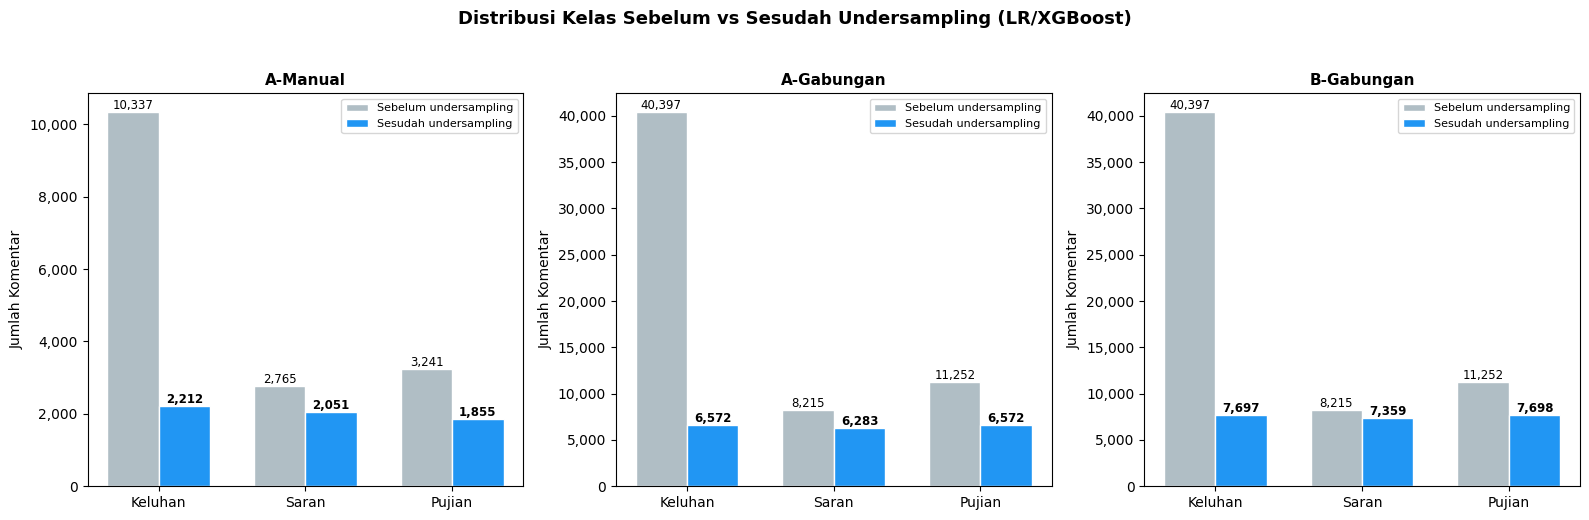

✅ Grafik LR/XGBoost disimpan ke outputs/figures/dist_sebelum_sesudah_undersampling_xgb.png


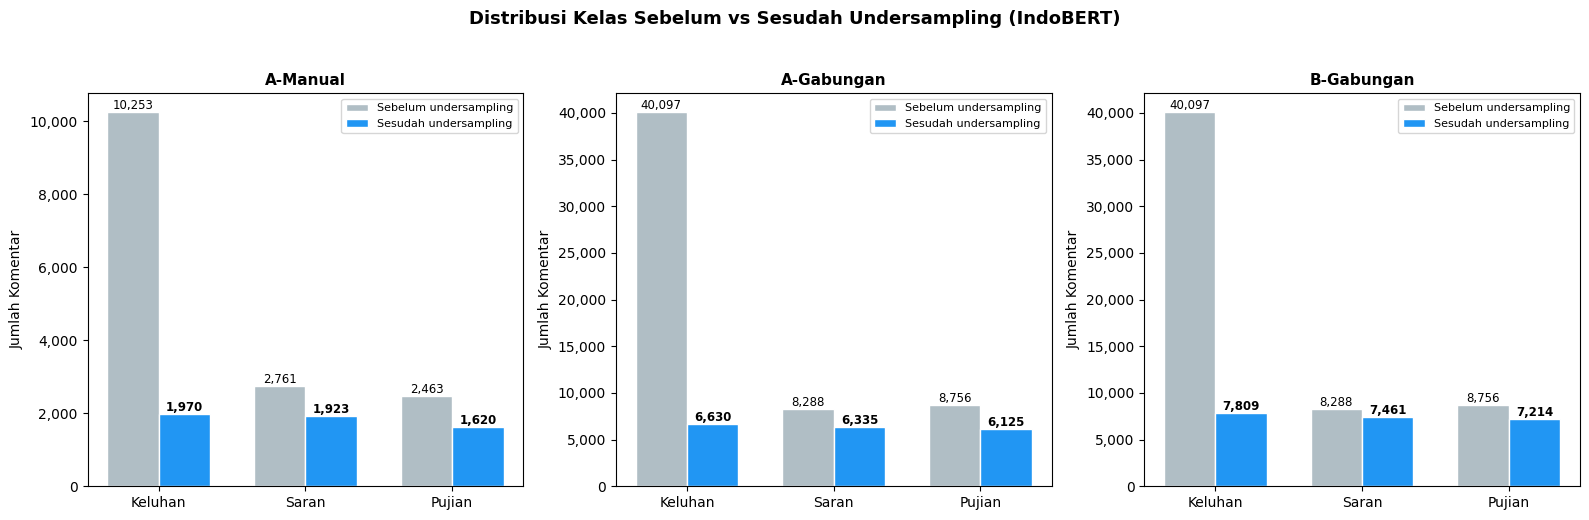

✅ Grafik IndoBERT disimpan ke outputs/figures/dist_sebelum_sesudah_undersampling_indobert.png

TABEL RINGKASAN: DISTRIBUSI KELAS SEBELUM vs SESUDAH UNDERSAMPLING
Skenario     Model      Kelas       Sebelum    Sesudah    Selisih
-----------------------------------------------------------------
A-Manual     LR/XGB     Keluhan      10,337      2,212     -8,125
A-Manual     LR/XGB     Saran         2,765      2,051       -714
A-Manual     LR/XGB     Pujian        3,241      1,855     -1,386
-----------------------------------------------------------------
A-Gabungan   LR/XGB     Keluhan      40,397      6,572    -33,825
A-Gabungan   LR/XGB     Saran         8,215      6,283     -1,932
A-Gabungan   LR/XGB     Pujian       11,252      6,572     -4,680
-----------------------------------------------------------------
B-Gabungan   LR/XGB     Keluhan      40,397      7,697    -32,700
B-Gabungan   LR/XGB     Saran         8,215      7,359       -856
B-Gabungan   LR/XGB     Pujian       11,252   

: 

In [ ]:
# ============================================================================
# Cell 3f — Visualisasi: Distribusi Kelas SEBELUM vs SESUDAH Undersampling
# Semua Skenario (A-Manual, A-Gabungan, B-Gabungan) — LR/XGB & IndoBERT
# ============================================================================
# Tempel cell ini SETELAH Cell 3e di notebook data_splitting_revisi.ipynb
# ============================================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

KELAS_ORDER = ['keluhan', 'saran', 'pujian']
KELAS_LABEL = ['Keluhan', 'Saran', 'Pujian']
WARNA_SEBELUM = '#B0BEC5'   # abu-abu (sebelum undersampling)
WARNA_SESUDAH = '#2196F3'   # biru   (sesudah undersampling)

def hitung_distribusi(df_, kolom_label):
    """Kembalikan Series jumlah per kelas, urut sesuai KELAS_ORDER."""
    vc = df_[kolom_label].value_counts()
    return [vc.get(k, 0) for k in KELAS_ORDER]

def plot_sebelum_sesudah(ax, nama_skenario, sebelum, sesudah):
    """Bar chart berdampingan: sebelum vs sesudah, per kelas."""
    x = range(len(KELAS_ORDER))
    lebar = 0.35

    bars1 = ax.bar([i - lebar/2 for i in x], sebelum, width=lebar,
                   label='Sebelum undersampling', color=WARNA_SEBELUM,
                   edgecolor='white', linewidth=1)
    bars2 = ax.bar([i + lebar/2 for i in x], sesudah, width=lebar,
                   label='Sesudah undersampling', color=WARNA_SESUDAH,
                   edgecolor='white', linewidth=1)

    # Label angka di atas tiap bar
    for bar, val in zip(bars1, sebelum):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{val:,}', ha='center', va='bottom', fontsize=8.5)
    for bar, val in zip(bars2, sesudah):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{val:,}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

    ax.set_xticks(list(x))
    ax.set_xticklabels(KELAS_LABEL)
    ax.set_title(nama_skenario, fontweight='bold', fontsize=11)
    ax.set_ylabel('Jumlah Komentar')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
    ax.legend(fontsize=8, loc='upper right')


# ============================================================================
# BAGIAN 1 — LR / XGBoost (3 skenario)
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribusi Kelas Sebelum vs Sesudah Undersampling (LR/XGBoost)',
             fontsize=13, fontweight='bold', y=1.03)

data_xgb = [
    ('A-Manual',   df_manual, man_train_bal),
    ('A-Gabungan', df_gab,    agab_train_bal),
    ('B-Gabungan', df_gab,    bgab_train_bal),
]

for ax, (nama, df_before, df_after) in zip(axes, data_xgb):
    sebelum = hitung_distribusi(df_before, 'label_pks')
    sesudah = hitung_distribusi(df_after, 'label_pks')
    plot_sebelum_sesudah(ax, nama, sebelum, sesudah)

plt.tight_layout()
plt.savefig('../outputs/figures/dist_sebelum_sesudah_undersampling_xgb.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik LR/XGBoost disimpan ke outputs/figures/dist_sebelum_sesudah_undersampling_xgb.png')


# ============================================================================
# BAGIAN 2 — IndoBERT (3 skenario)
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribusi Kelas Sebelum vs Sesudah Undersampling (IndoBERT)',
             fontsize=13, fontweight='bold', y=1.03)

data_idb = [
    ('A-Manual',   df_idb_manual, idb_man_train_bal),
    ('A-Gabungan', df_idb_gab,    idb_agab_train_bal),
    ('B-Gabungan', df_idb_gab,    idb_bgab_train_bal),
]

for ax, (nama, df_before, df_after) in zip(axes, data_idb):
    sebelum = hitung_distribusi(df_before, KOLOM_LABEL_IDB)
    sesudah = hitung_distribusi(df_after, KOLOM_LABEL_IDB)
    plot_sebelum_sesudah(ax, nama, sebelum, sesudah)

plt.tight_layout()
plt.savefig('../outputs/figures/dist_sebelum_sesudah_undersampling_indobert.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik IndoBERT disimpan ke outputs/figures/dist_sebelum_sesudah_undersampling_indobert.png')


# ============================================================================
# BAGIAN 3 — Tabel Ringkasan Angka (untuk dimasukkan ke skripsi)
# ============================================================================
print('\n' + '=' * 78)
print('TABEL RINGKASAN: DISTRIBUSI KELAS SEBELUM vs SESUDAH UNDERSAMPLING')
print('=' * 78)

semua_data = [
    ('A-Manual',   'LR/XGB',   df_manual,     man_train_bal,     'label_pks'),
    ('A-Gabungan', 'LR/XGB',   df_gab,        agab_train_bal,    'label_pks'),
    ('B-Gabungan', 'LR/XGB',   df_gab,        bgab_train_bal,    'label_pks'),
    ('A-Manual',   'IndoBERT', df_idb_manual, idb_man_train_bal, KOLOM_LABEL_IDB),
    ('A-Gabungan', 'IndoBERT', df_idb_gab,    idb_agab_train_bal,KOLOM_LABEL_IDB),
    ('B-Gabungan', 'IndoBERT', df_idb_gab,    idb_bgab_train_bal,KOLOM_LABEL_IDB),
]

header = f'{"Skenario":12s} {"Model":10s} {"Kelas":8s} {"Sebelum":>10s} {"Sesudah":>10s} {"Selisih":>10s}'
print(header)
print('-' * len(header))
for nama, model, df_before, df_after, kolom in semua_data:
    sebelum = hitung_distribusi(df_before, kolom)
    sesudah = hitung_distribusi(df_after, kolom)
    for kelas, s_before, s_after in zip(KELAS_LABEL, sebelum, sesudah):
        selisih = s_after - s_before
        print(f'{nama:12s} {model:10s} {kelas:8s} {s_before:>10,} {s_after:>10,} {selisih:>10,}')
    print('-' * len(header))